In [6]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.stats import linregress

from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from IPython.display import Audio
import os
from scipy.io.wavfile import write

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import GridSearchCV


base_path = '../../data/all_sorted'
classes = ['BIC', 'CAR', 'HEAVY', 'MC']

In [2]:
def remove_mains_hum(y, sr, hum_freqs=(50, 100, 150, 200), Q=30):
    """Uski notch filter na mreznoj frekvenciji i njenim harmonicima. Q=30 znaci vrlo uzak filter - makne samo usku vrpcu oko svake
    frekvencije, ne dira okolni spektar."""
    y_filt = y.copy()
    for f0 in hum_freqs:
        if f0 >= sr / 2:
            continue
        b, a = signal.iirnotch(f0, Q, sr)
        y_filt = signal.filtfilt(b, a, y_filt)
    return y_filt


def highpass(y, sr, cutoff=15, order=4):
    """Blagi high-pass da uklonimo vrlo niske frekvencije koje nam ne trebaju, koje mogu biti samo sum"""
    sos = signal.butter(order, cutoff, btype='highpass', fs=sr, output='sos')
    return signal.sosfiltfilt(sos, y)


def preprocess(y, sr):
    y = remove_mains_hum(y, sr)
    y = highpass(y, sr)
    return y


def bandpass_filter(y, sr, low, high, order=4):
    """Ako ce trebat...Opcenita bandpass funkcija, koristiti samo kao primjer za cuttanje da vidimo di se nalaze frekvencije, ne stavljati na 
    sve unisono prije modela"""
    sos = signal.butter(order, [low, high], btype='bandpass', fs=sr, output='sos')
    return signal.sosfiltfilt(sos, y)

In [3]:
def extract_features(y, sr):

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=5)

    feats = {
    }

    for i in range(5):
        feats[f'mfcc_{i}_mean'] = np.mean(mfcc[i])
        feats[f'mfcc_{i}_std'] = np.std(mfcc[i])

    return feats

In [5]:
CACHE_PATH = '../../data/features_cache/znacajke_cache_10.pkl'

if os.path.exists(CACHE_PATH):
    # Znacajke su vec izracunate i spremljene - samo ucitamo gotov DataFrame 
    df = pd.read_pickle(CACHE_PATH)
    print(f"Znacajke ucitane iz cachea: {CACHE_PATH} ({len(df)} uzoraka)")
else:
    data = []

    for label in classes:
        folder = os.path.join(base_path, label)
        files = [f for f in os.listdir(folder) if f.endswith('.wav')]

        for i, file in enumerate(files):
            path = os.path.join(folder, file)

            if i % 10 == 0:
                print(f"   {label}: {i}/{len(files)} -> {file}")

            y, sr = librosa.load(path, sr=None)
            y = y[:sr * 2]  # CLIP_SECONDS = 2
            y = preprocess(y, sr)

            feats = extract_features(y, sr)
            feats['label'] = label
            data.append(feats)

    print(f"\nGotovo! Ukupno uzoraka: {len(data)}")

    df = pd.DataFrame(data)
    df = df[[c for c in df.columns if c != 'label'] + ['label']]

    df.to_pickle(CACHE_PATH)
    print(f"Znacajke spremljene u cache: {CACHE_PATH}")

print("\nBroj uzoraka po klasi (provjera balansa):")
print(df['label'].value_counts())

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

df.head()

   BIC: 0/334 -> 583046e3-2023-10-15_15-42-8.0-Rathdowne4_TJN_NoV_L1_3Lanes_Idling_stereo.wav
   BIC: 10/334 -> 2023-08-02_13-13-46.0-Swanston5_FF_1V-Bic_L1_1Lane_RL_stereo.wav
   BIC: 20/334 -> 2023-08-01_16-6-13.5-Swanston1_FF_1V-Bic_L1_1Lane_RL_stereo.wav
   BIC: 30/334 -> 6df0d217-2023-08-04_10-25-39.0-Swanston6_TJN_NoV_L1_1Lane_Idling_mono.wav
   BIC: 40/334 -> 2023-10-15_15-17-37.6-Rathdowne3_FF_1V-Bic_L1_3Lanes_RL_stereo.wav
   BIC: 50/334 -> 683b1580-2023-10-15_15-29-12.0-Rathdowne3_FF_NoV_L1_3Lanes_Idling_stereo.wav
   BIC: 60/334 -> 2023-08-05_15-13-19.4-Swanston10_FF_1V-Bic_L1_1Lane_RL_stereo.wav
   BIC: 70/334 -> 250d3a1a-2023-08-04_12-7-24.0-Swanston7_TJN_NoV_L1_1Lane_Idling_mono.wav
   BIC: 80/334 -> 2023-10-15_15-47-20.5-Rathdowne3_FF_1V-Bic_L1_3Lanes_RL_stereo.wav
   BIC: 90/334 -> 1d8f36d8-2023-10-15_15-35-58.0-Rathdowne4_TJN_NoV_L1_3Lanes_Idling_stereo.wav
   BIC: 100/334 -> 2023-08-05_15-10-23.0-Swanston10_FF_1V-Bic_L1_1Lane_RL_stereo.wav
   BIC: 110/334 -> 2023-08-0

,mfcc_0_mean,mfcc_0_std,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,label
0,-256.685967,10.003626,178.775146,8.686232,-21.621541,5.821289,36.673271,4.580609,-1.047381,4.811483,BIC
1,-359.824522,22.649855,156.664657,11.681949,12.578587,7.050431,34.767883,6.372147,6.526522,8.544958,BIC
2,-327.811464,19.032952,167.932851,13.178547,2.001518,8.522644,37.542249,6.599697,-10.102805,7.831448,BIC
3,-357.119749,28.413603,140.353747,20.136714,-1.482174,10.328294,31.438115,6.909532,-8.179644,7.339408,BIC
4,-391.027884,13.254949,133.573605,16.001052,-39.154997,12.569525,36.705386,7.314667,-15.412616,6.875457,BIC


Train accuracy: 0.985
Test accuracy:  0.852
Razlika (train - test): 0.133
Zaustavljeno nakon 468 stabala (od maksimalnih 1000 dopustenih)
              precision    recall  f1-score   support

         BIC       0.58      0.63      0.60        83
         CAR       0.93      0.91      0.92      2337
       HEAVY       0.49      0.64      0.56       298
          MC       0.61      0.43      0.50       130

    accuracy                           0.85      2848
   macro avg       0.65      0.65      0.65      2848
weighted avg       0.86      0.85      0.85      2848



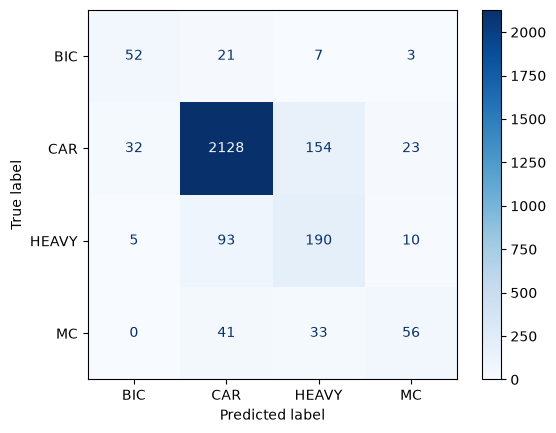

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_tr2, X_val, y_tr2, y_val = train_test_split(X_train, y_train_enc, test_size=0.2, stratify=y_train_enc, random_state=42)
weights_tr2 = compute_sample_weight('balanced', y_tr2)

clf_es = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    early_stopping_rounds=30, # model staje ako se validation score ne poboljša 30 iteracija zaredom
    random_state=42,
    n_jobs=-1,
)
clf_es.fit(
    X_tr2, y_tr2, sample_weight=weights_tr2,
    eval_set=[(X_val, y_val)],
    verbose=False
)

train_acc_es = clf_es.score(X_tr2, y_tr2)
test_acc_es = clf_es.score(X_test, y_test_enc)

print(f"Train accuracy: {train_acc_es:.3f}")
print(f"Test accuracy:  {test_acc_es:.3f}")
print(f"Razlika (train - test): {train_acc_es - test_acc_es:.3f}")


print(f"Zaustavljeno nakon {clf_es.best_iteration} stabala (od maksimalnih 1000 dopustenih)")

y_pred_es = le.inverse_transform(clf_es.predict(X_test))
print(classification_report(y_test, y_pred_es))

cm = confusion_matrix(y_test, y_pred_es)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.show()